# FIAP — Fase 6 — FarmTech Solutions
## Entrega principal — YOLO customizada, YOLO padrão e CNN

Este notebook foi reorganizado para conter **somente o que faz parte da entrega principal**.

### O que ficou neste arquivo
1. conferência do dataset;
2. validação dos labels YOLO;
3. treino YOLO customizado com 30 épocas;
4. treino YOLO customizado com 60 épocas;
5. comparação dos dois treinamentos;
6. teste dos dois modelos;
7. escolha automática do melhor modelo;
8. detecção final e exibição das imagens analisadas;
9. YOLO padrão pré-treinada para comparação;
10. CNN criada do zero;
11. métricas, matriz de confusão e exemplos de previsões;
12. comparação crítica final.

### O que foi removido daqui
- Transfer Learning;
- Fine Tuning;
- Segmentação automática;
- remoção de background.

Esses itens pertencem ao **IR ALÉM 2** e devem ficar em outro notebook.

> **Importante:** execute as células na ordem. Se reiniciar o kernel, use **Run All / Executar Tudo** novamente.

# 0. Estrutura esperada

O notebook deve ficar dentro de:

```text
ML_IMAGENS/
├── notebook/
│   ├── dataset/
│   │   ├── train/
│   │   │   ├── caneca/
│   │   │   └── garrafa/
│   │   ├── validation/
│   │   │   ├── caneca/
│   │   │   └── garrafa/
│   │   └── test/
│   │       ├── caneca/
│   │       └── garrafa/
│   ├── dataset_yolo/
│   │   ├── images/
│   │   │   ├── train/
│   │   │   ├── val/
│   │   │   └── test/
│   │   └── labels/
│   │       ├── train/
│   │       ├── val/
│   │       └── test/
│   ├── yolov5/
│   └── ESTE_NOTEBOOK.ipynb
└── venv/
```

Classes usadas pela YOLO:

- `0 = garrafa`
- `1 = caneca`

Cada imagem YOLO precisa de um `.txt` com o mesmo nome:

```text
classe x_centro y_centro largura altura
```

Todos os valores geométricos devem estar normalizados entre `0` e `1`.

# 1. Importações leves — etapa YOLO

In [1]:
import os
import sys
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml

print("Python:", sys.version.split()[0])
print("Executável:", sys.executable)

Python: 3.13.2
Executável: /home/debianjv/Documentos/ML_IMAGENS/venv/bin/python


# 2. Configuração do projeto

In [2]:
PROJECT_DIR = Path.cwd()

CLASS_DATASET_DIR = PROJECT_DIR / "dataset"
YOLO_DATASET_DIR = PROJECT_DIR / "dataset_yolo"
YOLO_REPO_DIR = PROJECT_DIR / "yolov5"

YOLO_CLASS_NAMES = ["garrafa", "caneca"]

# CNN
IMG_SIZE = (160, 160)
BATCH_SIZE = 4
SEED = 42

# Máquina sem CUDA funcional
DEVICE = "cpu"

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

print("Pasta atual:", PROJECT_DIR)
print("dataset existe:", CLASS_DATASET_DIR.exists())
print("dataset_yolo existe:", YOLO_DATASET_DIR.exists())
print("yolov5 existe:", YOLO_REPO_DIR.exists())

if not CLASS_DATASET_DIR.exists():
    raise FileNotFoundError(CLASS_DATASET_DIR)

if not YOLO_DATASET_DIR.exists():
    raise FileNotFoundError(YOLO_DATASET_DIR)

if not YOLO_REPO_DIR.exists():
    raise FileNotFoundError(YOLO_REPO_DIR)

Pasta atual: /home/debianjv/Documentos/ML_IMAGENS/notebook
dataset existe: True
dataset_yolo existe: True
yolov5 existe: True


# 3. Funções auxiliares e validação dos labels

Um arquivo pode existir e ainda estar errado. Por isso, não basta contar os `.txt`.

A função abaixo verifica se cada label:

- pode ser lido como texto;
- possui exatamente 5 valores por linha;
- usa apenas as classes `0` ou `1`;
- possui coordenadas entre `0` e `1`.

In [3]:
def listar_imagens(pasta):
    if not pasta.exists():
        return []

    return sorted(
        p for p in pasta.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def label_yolo_valido(txt_path):
    try:
        texto = txt_path.read_text(encoding="utf-8")
    except Exception:
        return False

    linhas = [
        linha.strip()
        for linha in texto.splitlines()
        if linha.strip()
    ]

    if not linhas:
        return False

    for linha in linhas:
        partes = linha.split()

        if len(partes) != 5:
            return False

        try:
            classe = int(float(partes[0]))
            valores = [float(v) for v in partes[1:5]]
        except ValueError:
            return False

        if classe not in (0, 1):
            return False

        if not all(0.0 <= v <= 1.0 for v in valores):
            return False

    return True


def validar_labels_yolo():
    problemas = []

    for split in ["train", "val", "test"]:
        img_dir = YOLO_DATASET_DIR / "images" / split
        lbl_dir = YOLO_DATASET_DIR / "labels" / split

        for imagem in listar_imagens(img_dir):
            label = lbl_dir / f"{imagem.stem}.txt"

            if not label.exists():
                problemas.append(
                    f"{split}: sem label -> {imagem.name}"
                )
                continue

            if not label_yolo_valido(label):
                problemas.append(
                    f"{split}: label inválido -> {label.name}"
                )

    if problemas:
        print("Foram encontrados problemas nos labels:\n")

        for problema in problemas:
            print("-", problema)

        return False

    print("OK: todas as imagens possuem labels YOLO válidos.")
    return True

# 4. Conferência das quantidades

In [4]:
print("=== DATASET YOLO ===")

for split in ["train", "val", "test"]:
    img_dir = YOLO_DATASET_DIR / "images" / split
    lbl_dir = YOLO_DATASET_DIR / "labels" / split

    imagens = listar_imagens(img_dir)

    labels = [
        p for p in lbl_dir.glob("*.txt")
        if label_yolo_valido(p)
    ]

    print(
        f"{split:5} | "
        f"imagens={len(imagens):3} | "
        f"labels válidos={len(labels):3}"
    )

print("\n=== DATASET DE CLASSIFICAÇÃO ===")

for split in ["train", "validation", "test"]:
    pasta = CLASS_DATASET_DIR / split

    print(f"\n{split}")

    if not pasta.exists():
        print("Pasta não encontrada.")
        continue

    for classe in sorted(
        p for p in pasta.iterdir()
        if p.is_dir()
    ):
        print(
            f"{classe.name}: "
            f"{len(listar_imagens(classe))}"
        )

LABELS_OK = validar_labels_yolo()

=== DATASET YOLO ===
train | imagens= 64 | labels válidos= 63
val   | imagens=  8 | labels válidos=  8
test  | imagens=  8 | labels válidos=  8

=== DATASET DE CLASSIFICAÇÃO ===

train
caneca: 32
garrafa: 32

validation
caneca: 4
garrafa: 4

test
caneca: 4
garrafa: 4
OK: todas as imagens possuem labels YOLO válidos.


# 5. Revisão visual dos labels YOLO

Um label pode ser numericamente válido e ainda ter uma bounding box ruim.

Esta etapa mostra as caixas do dataset antes do treinamento.

A caixa deve envolver o objeto inteiro ou quase inteiro. Se aparecer somente na tampa, base ou alça, o label precisa ser corrigido antes de treinar.

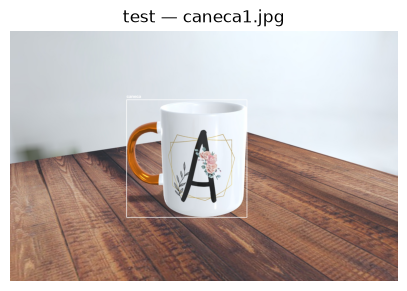

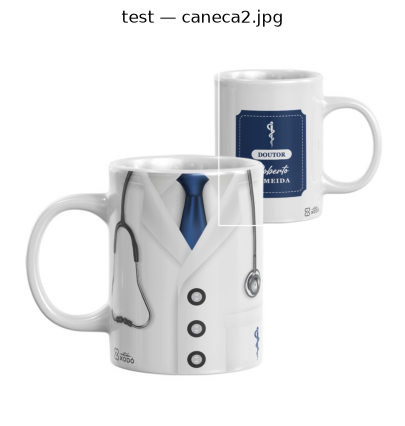

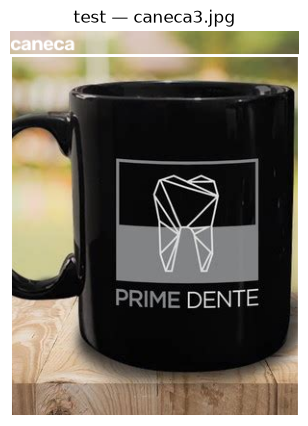

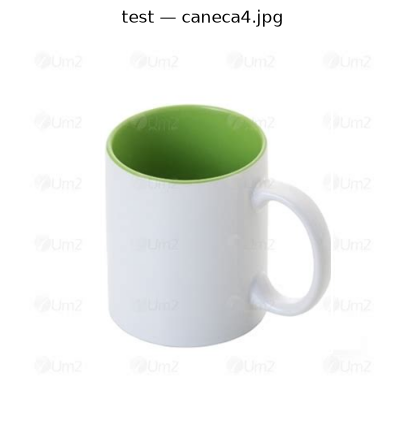

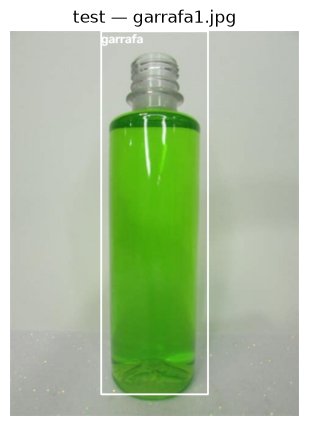

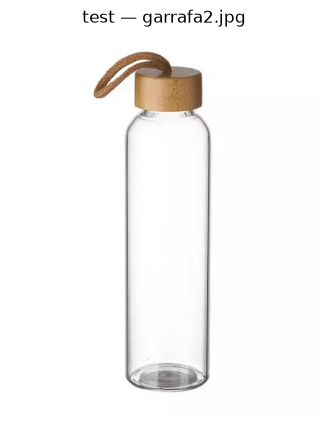

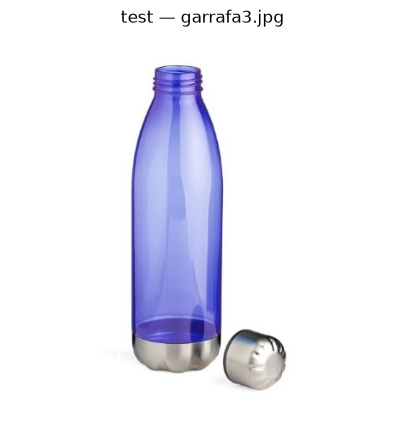

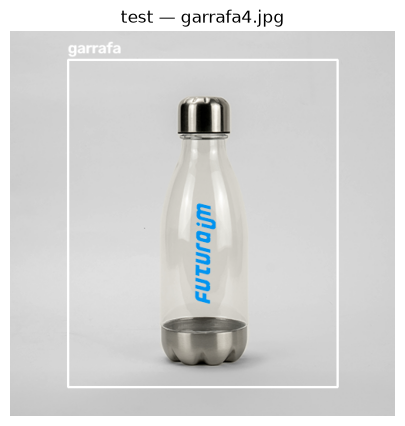

In [5]:
def carregar_boxes_yolo(imagem_path, label_path):
    img = cv2.imread(str(imagem_path))

    if img is None:
        raise ValueError(f"Não foi possível abrir: {imagem_path}")

    h, w = img.shape[:2]
    boxes = []

    for linha in label_path.read_text(encoding="utf-8").splitlines():
        partes = linha.split()

        if len(partes) != 5:
            continue

        classe = int(float(partes[0]))
        xc, yc, bw, bh = map(float, partes[1:5])

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        boxes.append((classe, x1, y1, x2, y2))

    return img, boxes


def mostrar_revisao_yolo(split, max_imagens=8):
    img_dir = YOLO_DATASET_DIR / "images" / split
    lbl_dir = YOLO_DATASET_DIR / "labels" / split

    for imagem_path in listar_imagens(img_dir)[:max_imagens]:
        label_path = lbl_dir / f"{imagem_path.stem}.txt"

        if not label_path.exists() or not label_yolo_valido(label_path):
            continue

        img, boxes = carregar_boxes_yolo(
            imagem_path,
            label_path
        )

        for classe, x1, y1, x2, y2 in boxes:
            nome = YOLO_CLASS_NAMES[classe]

            cv2.rectangle(
                img,
                (x1, y1),
                (x2, y2),
                (255, 255, 255),
                2
            )

            cv2.putText(
                img,
                nome,
                (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f"{split} — {imagem_path.name}")
        plt.axis("off")
        plt.show()


mostrar_revisao_yolo(
    "test",
    max_imagens=8
)

# 6. Gerar o arquivo YAML da YOLO

In [6]:
if not LABELS_OK:
    raise RuntimeError(
        "Existem labels ausentes ou inválidos. "
        "Corrija antes de continuar."
    )

data_yaml = {
    "path": str(YOLO_DATASET_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(YOLO_CLASS_NAMES),
    "names": YOLO_CLASS_NAMES
}

DATA_YAML_PATH = PROJECT_DIR / "fase6_data.yaml"

with DATA_YAML_PATH.open(
    "w",
    encoding="utf-8"
) as f:
    yaml.safe_dump(
        data_yaml,
        f,
        allow_unicode=True,
        sort_keys=False
    )

print(DATA_YAML_PATH.read_text(encoding="utf-8"))

path: /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo
train: images/train
val: images/val
test: images/test
nc: 2
names:
- garrafa
- caneca



# ENTREGA 1 — YOLO CUSTOMIZADA

Serão feitos dois treinamentos com os mesmos parâmetros.

A única diferença será:

- experimento 1: `30 épocas`;
- experimento 2: `60 épocas`.

Isso permite analisar se aumentar as épocas trouxe ganho real.

Para a máquina sem GPU usamos:

- `yolov5n.pt`;
- imagem `320`;
- batch `2`;
- `workers = 0`;
- CPU.

# 7. Treino YOLO — 30 épocas

In [7]:
EXP30_NAME = "fase6_30_final"

cmd_30 = [
    sys.executable,
    str(YOLO_REPO_DIR / "train.py"),
    "--img", "320",
    "--batch", "2",
    "--epochs", "30",
    "--data", str(DATA_YAML_PATH),
    "--weights", "yolov5n.pt",
    "--device", DEVICE,
    "--workers", "0",
    "--name", EXP30_NAME,
    "--exist-ok"
]

inicio = time.perf_counter()

subprocess.run(
    cmd_30,
    cwd=YOLO_REPO_DIR,
    check=True
)

TEMPO_TREINO_30 = time.perf_counter() - inicio

print(
    f"Treino de 30 épocas concluído em "
    f"{TEMPO_TREINO_30:.2f} s"
)

I0000 00:00:1790702565.966555   50525 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790702567.036432   50525 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790702567.036870   50525 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


train: weights=yolov5n.pt, cfg=, data=/home/debianjv/Documentos/ML_IMAGENS/notebook/fase6_data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=2, imgsz=320, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=cpu, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=0, project=runs/train, name=fase6_30_final, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-553-g402e17dd Python-3.13.2 torch-2.14.0+cu130 CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2

# 8. Treino YOLO — 60 épocas

In [8]:
EXP60_NAME = "fase6_60_final"

cmd_60 = [
    sys.executable,
    str(YOLO_REPO_DIR / "train.py"),
    "--img", "320",
    "--batch", "2",
    "--epochs", "60",
    "--data", str(DATA_YAML_PATH),
    "--weights", "yolov5n.pt",
    "--device", DEVICE,
    "--workers", "0",
    "--name", EXP60_NAME,
    "--exist-ok"
]

inicio = time.perf_counter()

subprocess.run(
    cmd_60,
    cwd=YOLO_REPO_DIR,
    check=True
)

TEMPO_TREINO_60 = time.perf_counter() - inicio

print(
    f"Treino de 60 épocas concluído em "
    f"{TEMPO_TREINO_60:.2f} s"
)

I0000 00:00:1790702692.167808   51921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790702693.167038   51921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790702693.167509   51921 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


train: weights=yolov5n.pt, cfg=, data=/home/debianjv/Documentos/ML_IMAGENS/notebook/fase6_data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=60, batch_size=2, imgsz=320, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=cpu, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=0, project=runs/train, name=fase6_60_final, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-553-g402e17dd Python-3.13.2 torch-2.14.0+cu130 CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2

# 9. Carregar os resultados dos dois treinamentos

O YOLOv5 grava um `results.csv` dentro de cada experimento.

Vamos usar esse arquivo para comparar:

- Precision;
- Recall;
- mAP@0.5;
- mAP@0.5:0.95.

### Interpretação

**Precision:** das detecções feitas, quantas estavam corretas.

**Recall:** dos objetos existentes, quantos foram encontrados.

**mAP@0.5:** qualidade geral das detecções com IoU 0,5.

**mAP@0.5:0.95:** avaliação mais rigorosa em vários níveis de IoU.

In [9]:
YOLO_TRAIN_DIR = YOLO_REPO_DIR / "runs" / "train"


def carregar_resultados_yolo(exp_name):
    csv_path = YOLO_TRAIN_DIR / exp_name / "results.csv"

    if not csv_path.exists():
        raise FileNotFoundError(
            f"Resultado não encontrado: {csv_path}"
        )

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    return df


df_yolo_30 = carregar_resultados_yolo(
    EXP30_NAME
)

df_yolo_60 = carregar_resultados_yolo(
    EXP60_NAME
)

display(df_yolo_30.tail())
display(df_yolo_60.tail())

,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
25,25,0.058144,0.022022,0.021529,0.23169,0.500,0.37606,0.22588,0.035385,0.006293,0.014279,0.00208,0.00208,0.00208
26,26,0.055096,0.022136,0.021001,0.19226,0.500,0.29014,0.19622,0.035704,0.006328,0.014501,0.00175,0.00175,0.00175
27,27,0.056341,0.021467,0.022089,0.20156,0.500,0.32249,0.19940,0.034338,0.006322,0.013795,0.00142,0.00142,0.00142
28,28,0.054683,0.021541,0.020461,0.34236,0.375,0.35840,0.24349,0.034276,0.006342,0.013697,0.00109,0.00109,0.00109
29,29,0.055575,0.021136,0.020705,0.23608,0.250,0.33947,0.21343,0.035499,0.006296,0.013820,0.00076,0.00076,0.00076


,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
55,55,0.044713,0.018290,0.017852,0.77609,0.75000,0.86286,0.55014,0.020251,0.004674,0.009758,0.001090,0.001090,0.001090
56,56,0.045528,0.019849,0.019629,0.74424,0.75000,0.86286,0.59187,0.020599,0.004703,0.009769,0.000925,0.000925,0.000925
57,57,0.046267,0.019385,0.017457,0.76897,0.75000,0.82139,0.47656,0.021314,0.004788,0.010073,0.000760,0.000760,0.000760
58,58,0.050675,0.019573,0.019468,0.74573,0.71003,0.83389,0.50314,0.021208,0.004807,0.009700,0.000595,0.000595,0.000595
59,59,0.044140,0.019839,0.019942,0.77284,0.75000,0.83250,0.49916,0.020784,0.004739,0.010302,0.000430,0.000430,0.000430


In [10]:
def achar_coluna(df, candidatos):
    for coluna in df.columns:
        normalizada = (
            coluna.lower()
            .replace(" ", "")
        )

        for candidato in candidatos:
            alvo = (
                candidato.lower()
                .replace(" ", "")
            )

            if alvo in normalizada:
                return coluna

    return None


COL_PREC = achar_coluna(
    df_yolo_30,
    ["precision"]
)

COL_REC = achar_coluna(
    df_yolo_30,
    ["recall"]
)

COL_MAP50 = achar_coluna(
    df_yolo_30,
    ["map_0.5", "map50"]
)

COL_MAP5095 = achar_coluna(
    df_yolo_30,
    ["map_0.5:0.95", "map50-95"]
)

print("Precision:", COL_PREC)
print("Recall:", COL_REC)
print("mAP50:", COL_MAP50)
print("mAP50-95:", COL_MAP5095)

Precision: metrics/precision
Recall: metrics/recall
mAP50: metrics/mAP_0.5
mAP50-95: metrics/mAP_0.5:0.95


# 10. Gráficos — 30 × 60 épocas

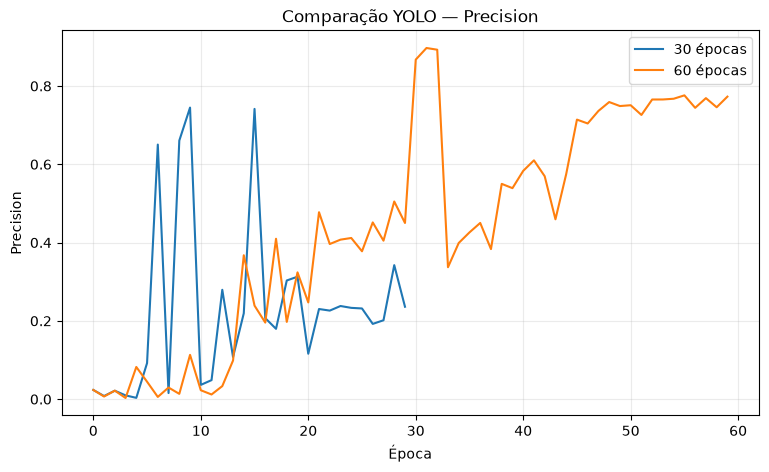

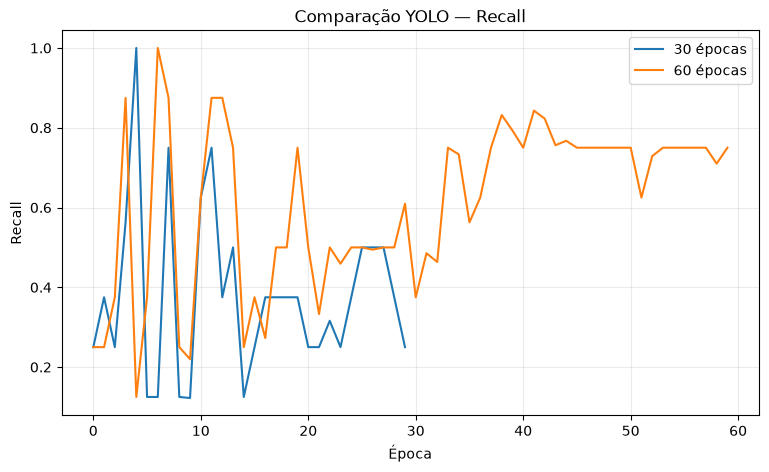

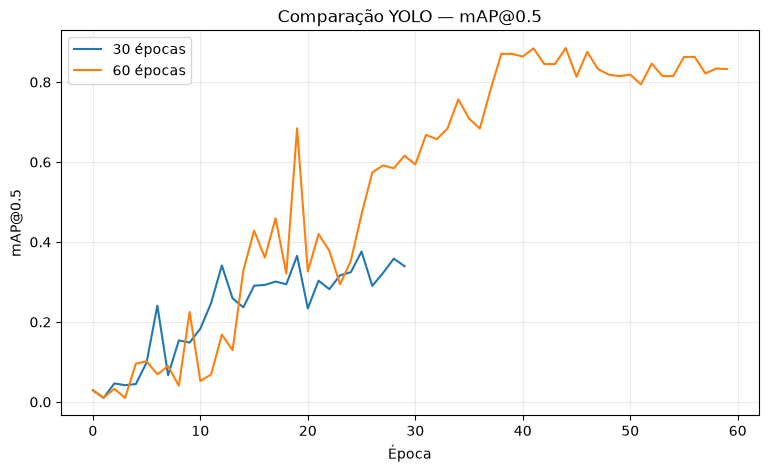

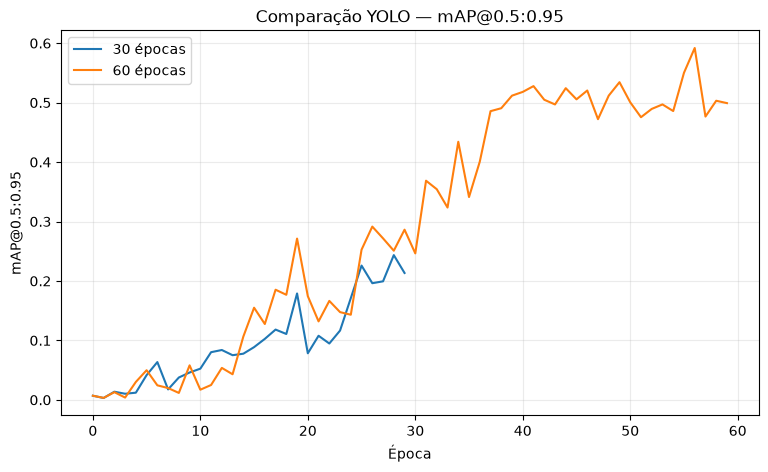

In [11]:
def plotar_comparacao_yolo(coluna, titulo):
    if coluna is None:
        print(f"Métrica não encontrada: {titulo}")
        return

    plt.figure(figsize=(9, 5))

    plt.plot(
        df_yolo_30[coluna].values,
        label="30 épocas"
    )

    plt.plot(
        df_yolo_60[coluna].values,
        label="60 épocas"
    )

    plt.xlabel("Época")
    plt.ylabel(titulo)
    plt.title(f"Comparação YOLO — {titulo}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


plotar_comparacao_yolo(
    COL_PREC,
    "Precision"
)

plotar_comparacao_yolo(
    COL_REC,
    "Recall"
)

plotar_comparacao_yolo(
    COL_MAP50,
    "mAP@0.5"
)

plotar_comparacao_yolo(
    COL_MAP5095,
    "mAP@0.5:0.95"
)

# 11. Escolha automática do melhor YOLO

In [12]:
BEST_30 = (
    YOLO_TRAIN_DIR
    / EXP30_NAME
    / "weights"
    / "best.pt"
)

BEST_60 = (
    YOLO_TRAIN_DIR
    / EXP60_NAME
    / "weights"
    / "best.pt"
)

metric_col = (
    COL_MAP5095
    if COL_MAP5095 is not None
    else COL_MAP50
)

if metric_col is None:
    raise RuntimeError(
        "Nenhuma coluna de mAP foi encontrada."
    )

score_30 = float(
    df_yolo_30[metric_col].max()
)

score_60 = float(
    df_yolo_60[metric_col].max()
)

if score_60 >= score_30:
    YOLO_CUSTOM_BEST = BEST_60
    MELHOR_EXP = EXP60_NAME
else:
    YOLO_CUSTOM_BEST = BEST_30
    MELHOR_EXP = EXP30_NAME

print("Métrica usada:", metric_col)
print("Melhor valor 30 épocas:", score_30)
print("Melhor valor 60 épocas:", score_60)
print("Experimento escolhido:", MELHOR_EXP)
print("Pesos:", YOLO_CUSTOM_BEST)

Métrica usada: metrics/mAP_0.5:0.95
Melhor valor 30 épocas: 0.24349
Melhor valor 60 épocas: 0.59187
Experimento escolhido: fase6_60_final
Pesos: /home/debianjv/Documentos/ML_IMAGENS/notebook/yolov5/runs/train/fase6_60_final/weights/best.pt


# 12. Teste dos dois modelos YOLO

In [13]:
def testar_yolo(
    weights_path,
    nome
):
    cmd = [
        sys.executable,
        str(YOLO_REPO_DIR / "val.py"),
        "--weights", str(weights_path),
        "--data", str(DATA_YAML_PATH),
        "--img", "320",
        "--batch-size", "2",
        "--task", "test",
        "--device", DEVICE,
        "--workers", "0",
        "--name", nome,
        "--exist-ok"
    ]

    subprocess.run(
        cmd,
        cwd=YOLO_REPO_DIR,
        check=True
    )


testar_yolo(
    BEST_30,
    "teste_30_final"
)

testar_yolo(
    BEST_60,
    "teste_60_final"
)

val: data=/home/debianjv/Documentos/ML_IMAGENS/notebook/fase6_data.yaml, weights=['/home/debianjv/Documentos/ML_IMAGENS/notebook/yolov5/runs/train/fase6_30_final/weights/best.pt'], batch_size=2, imgsz=320, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=cpu, workers=0, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=teste_30_final, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-553-g402e17dd Python-3.13.2 torch-2.14.0+cu130 CPU

Fusing layers... 
Model summary: 68 layers, 1,761,871 parameters, 0 gradients
test: Scanning /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 4/4 20.1it/s 0.2s.4s
                   all          8          8      0.416       0.25      0.334      0.151
               garrafa       

# 13. Detecção final com o melhor modelo

Agora usamos o melhor `best.pt` nas imagens de teste.

As imagens resultantes devem mostrar:

- bounding box;
- classe;
- confiança.

Isso permite analisar visualmente erros que não aparecem apenas nas métricas.

In [14]:
TEST_IMAGES_DIR = (
    YOLO_DATASET_DIR
    / "images"
    / "test"
)

FINAL_DETECT_NAME = "fase6_teste_final"

cmd_detect_final = [
    sys.executable,
    str(YOLO_REPO_DIR / "detect.py"),
    "--weights", str(YOLO_CUSTOM_BEST),
    "--source", str(TEST_IMAGES_DIR),
    "--img", "320",
    "--conf", "0.25",
    "--device", DEVICE,
    "--name", FINAL_DETECT_NAME,
    "--exist-ok"
]

subprocess.run(
    cmd_detect_final,
    cwd=YOLO_REPO_DIR,
    check=True
)

DETECT_OUTPUT_DIR = (
    YOLO_REPO_DIR
    / "runs"
    / "detect"
    / FINAL_DETECT_NAME
)

print(
    "Resultados:",
    DETECT_OUTPUT_DIR
)

detect: weights=['/home/debianjv/Documentos/ML_IMAGENS/notebook/yolov5/runs/train/fase6_60_final/weights/best.pt'], source=/home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/images/test, data=data/coco128.yaml, imgsz=[320, 320], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=cpu, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=fase6_teste_final, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-553-g402e17dd Python-3.13.2 torch-2.14.0+cu130 CPU

Fusing layers... 
Model summary: 68 layers, 1,761,871 parameters, 0 gradients
image 1/8 /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/images/test/caneca1.jpg: 224x320 2 canecas, 16.6ms
image 2/8 /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/images/test/caneca2.jpg: 320x320 2 canecas, 18.

# 14. Mostrar as imagens analisadas pela YOLO customizada

Imagens geradas: 8


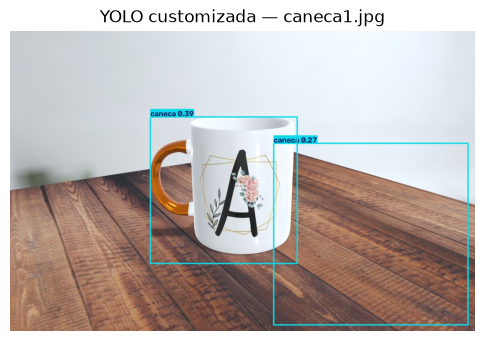

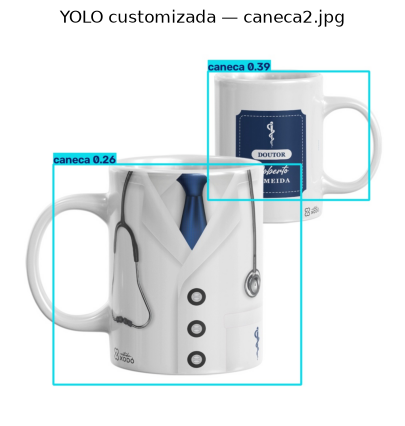

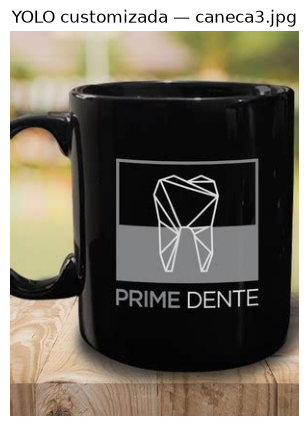

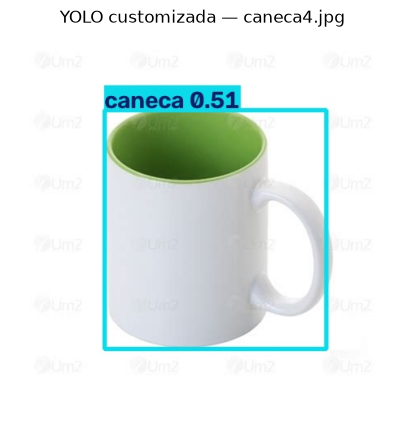

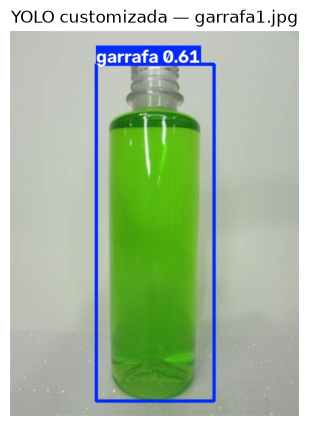

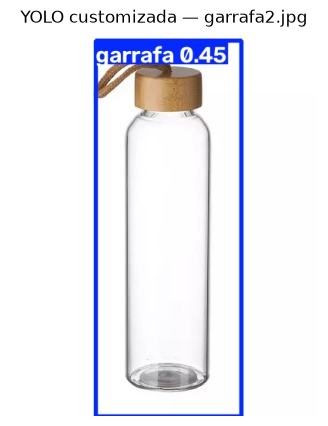

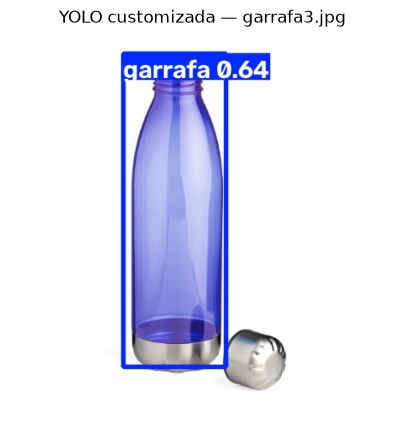

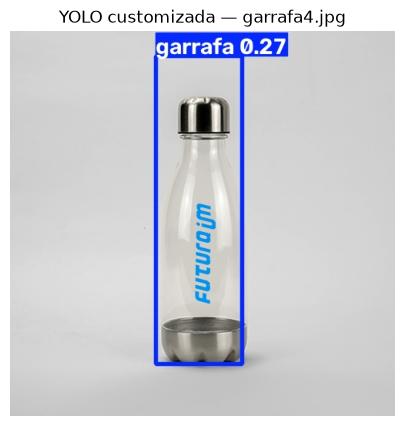

In [15]:
imagens_detectadas = listar_imagens(
    DETECT_OUTPUT_DIR
)

print(
    "Imagens geradas:",
    len(imagens_detectadas)
)

for imagem_path in imagens_detectadas[:8]:
    img = cv2.imread(
        str(imagem_path)
    )

    if img is None:
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(
        f"YOLO customizada — "
        f"{imagem_path.name}"
    )
    plt.axis("off")
    plt.show()

# ENTREGA 2 — YOLO PADRÃO + CNN DO ZERO

A entrega também pede uma comparação com uma YOLO pré-treinada.

Nesta etapa **não treinamos** a YOLO padrão.

Usamos diretamente os pesos `yolov5s.pt` para observar como um modelo genérico se comporta nas mesmas imagens.

# 15. YOLO padrão — inferência

In [16]:
PADRAO_NAME = "fase6_yolo_padrao"

cmd_yolo_padrao = [
    sys.executable,
    str(YOLO_REPO_DIR / "detect.py"),
    "--weights", "yolov5s.pt",
    "--source", str(TEST_IMAGES_DIR),
    "--img", "320",
    "--conf", "0.25",
    "--device", DEVICE,
    "--name", PADRAO_NAME,
    "--exist-ok"
]

inicio = time.perf_counter()

subprocess.run(
    cmd_yolo_padrao,
    cwd=YOLO_REPO_DIR,
    check=True
)

TEMPO_YOLO_PADRAO = (
    time.perf_counter()
    - inicio
)

PADRAO_OUTPUT_DIR = (
    YOLO_REPO_DIR
    / "runs"
    / "detect"
    / PADRAO_NAME
)

print(
    f"Tempo YOLO padrão: "
    f"{TEMPO_YOLO_PADRAO:.2f} s"
)

detect: weights=['yolov5s.pt'], source=/home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/images/test, data=data/coco128.yaml, imgsz=[320, 320], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=cpu, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=fase6_yolo_padrao, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-553-g402e17dd Python-3.13.2 torch-2.14.0+cu130 CPU

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients
image 1/8 /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/images/test/caneca1.jpg: 224x320 1 cup, 1 dining table, 27.9ms
image 2/8 /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo/images/test/caneca2.jpg: 320x320 2 cups, 35.5ms
image 3/8 /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset_yolo

# 16. Mostrar as imagens analisadas pela YOLO padrão

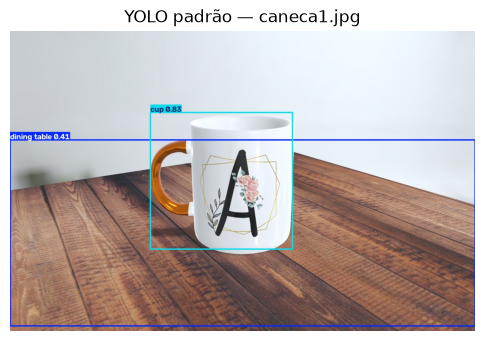

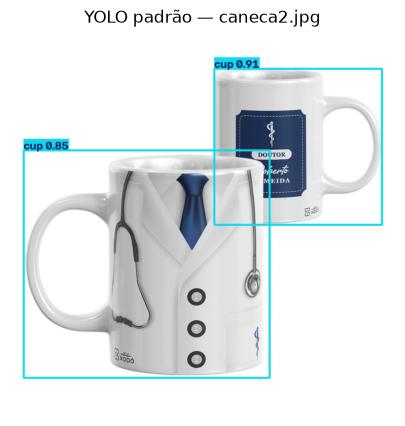

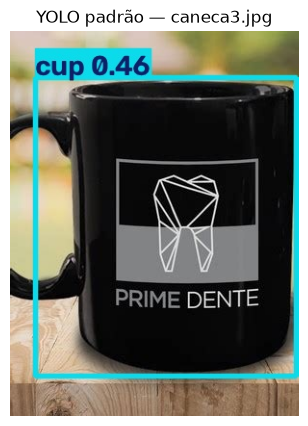

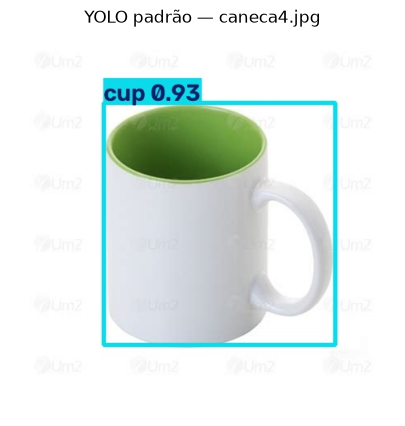

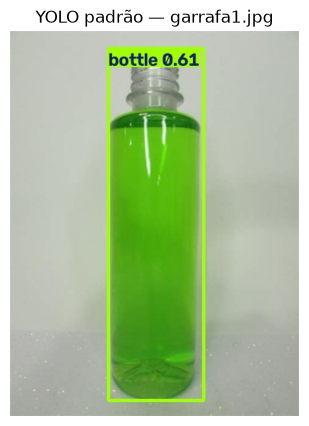

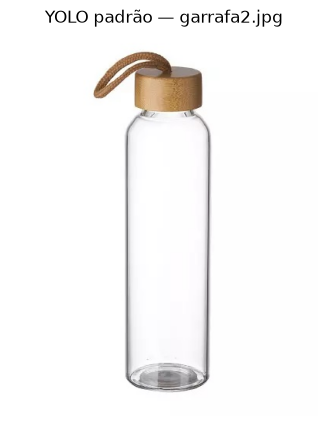

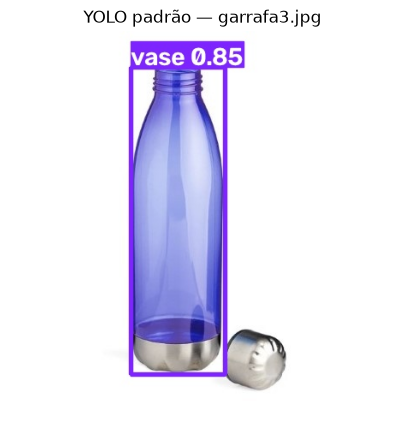

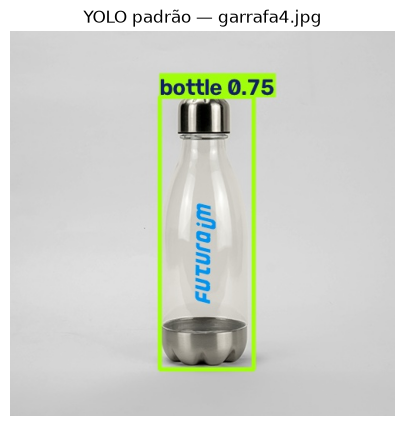

In [17]:
imagens_padrao = listar_imagens(
    PADRAO_OUTPUT_DIR
)

for imagem_path in imagens_padrao[:8]:
    img = cv2.imread(
        str(imagem_path)
    )

    if img is None:
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(
        f"YOLO padrão — "
        f"{imagem_path.name}"
    )
    plt.axis("off")
    plt.show()

# 17. TensorFlow — CNN do zero

A partir daqui entramos na parte de classificação.

A CNN não localiza o objeto com bounding box. Ela recebe a imagem inteira e decide entre:

- `caneca`;
- `garrafa`.

TensorFlow é carregado apenas agora para evitar manter PyTorch/YOLO e TensorFlow pesados ao mesmo tempo durante os treinamentos YOLO.

In [18]:
import tensorflow as tf

from tensorflow.keras import (
    layers,
    models
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow:", tf.__version__)
print(
    "GPU TensorFlow:",
    tf.config.list_physical_devices("GPU")
)

I0000 00:00:1790703004.004650   50070 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790703004.005201   50070 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790703004.034582   50070 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790703004.994209   50070 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow: 2.21.0
GPU TensorFlow: []


E0000 00:00:1790703005.610537   50070 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 18. Carregar o dataset de classificação

In [19]:
TRAIN_DIR = (
    CLASS_DATASET_DIR
    / "train"
)

VAL_DIR = (
    CLASS_DATASET_DIR
    / "validation"
)

TEST_CLASS_DIR = (
    CLASS_DATASET_DIR
    / "test"
)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_CLASS_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

CLASSIFICATION_NAMES = train_ds.class_names

print(
    "Classes TensorFlow:",
    CLASSIFICATION_NAMES
)

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Classes TensorFlow: ['caneca', 'garrafa']


# 19. Mostrar exemplos que a CNN recebe

O TensorFlow ordena os nomes das pastas alfabeticamente.

Por isso, neste dataset normalmente teremos:

- `0 = caneca`
- `1 = garrafa`

Essa numeração é independente da numeração da YOLO.

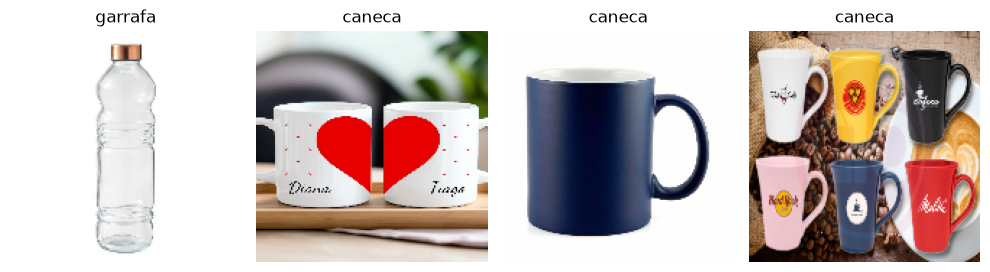

In [20]:
plt.figure(figsize=(10, 7))

for imagens, labels in train_ds.take(1):
    limite = min(
        8,
        len(imagens)
    )

    for i in range(limite):
        plt.subplot(
            2,
            4,
            i + 1
        )

        plt.imshow(
            imagens[i]
            .numpy()
            .astype("uint8")
        )

        idx = int(
            labels[i]
            .numpy()
            .ravel()[0]
        )

        plt.title(
            CLASSIFICATION_NAMES[idx]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

# 20. Data Augmentation

O dataset é pequeno.

Por isso aplicamos alterações leves durante o treinamento:

- espelhamento horizontal;
- pequena rotação;
- zoom;
- pequena variação de contraste.

Essas transformações ajudam a CNN a não memorizar somente as imagens originais.

In [21]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),
        layers.RandomRotation(
            0.05
        ),
        layers.RandomZoom(
            0.08
        ),
        layers.RandomContrast(
            0.05
        )
    ],
    name="data_augmentation"
)

# 21. Callbacks da CNN

In [22]:
callbacks_cnn = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

print("Callbacks da CNN definidos.")

Callbacks da CNN definidos.


# 22. Construção da CNN do zero

Arquitetura:

1. normalização dos pixels;
2. Data Augmentation;
3. convolução 32 filtros;
4. pooling;
5. convolução 64 filtros;
6. pooling;
7. convolução 128 filtros;
8. pooling;
9. Global Average Pooling;
10. camada densa;
11. dropout;
12. saída sigmoid.

A saída `sigmoid` é adequada porque temos somente duas classes.

In [23]:
cnn_model = models.Sequential([
    layers.Input(
        shape=(
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        )
    ),

    layers.Rescaling(
        1.0 / 255
    ),

    data_augmentation,

    layers.Conv2D(
        32,
        3,
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(
        0.30
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

# 23. Treinamento da CNN

In [24]:
inicio = time.perf_counter()

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_cnn,
    verbose=1
)

TEMPO_CNN = (
    time.perf_counter()
    - inicio
)

print(
    f"Tempo CNN: "
    f"{TEMPO_CNN:.2f} s"
)

Epoch 1/20


/home/debianjv/Documentos/ML_IMAGENS/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5156 - loss: 0.7040 - precision: 0.5556 - recall: 0.1562 - val_accuracy: 0.5000 - val_loss: 0.6909 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.5000 - recall: 0.1250 - val_accuracy: 0.5000 - val_loss: 0.6851 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5625 - loss: 0.6876 - precision: 0.7000 - recall: 0.2188 - val_accuracy: 0.5000 - val_loss: 0.6817 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5156 - loss: 0.7050 - precision: 1.0000 - recall: 0.0312 - val_accuracy: 0.5000 - val_loss: 0.6712 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/s

# 24. Curvas da CNN

### Accuracy
Mostra a proporção de acertos.

### Loss
Mostra o erro do modelo.

Um possível sinal de overfitting ocorre quando:

- o treino continua melhorando;
- a validação para de melhorar ou piora.

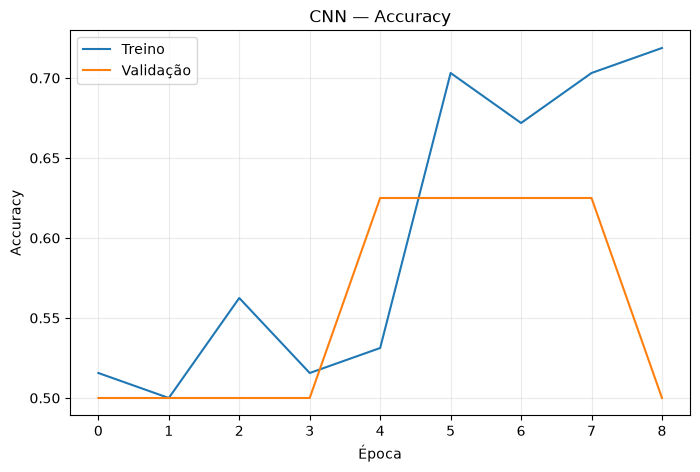

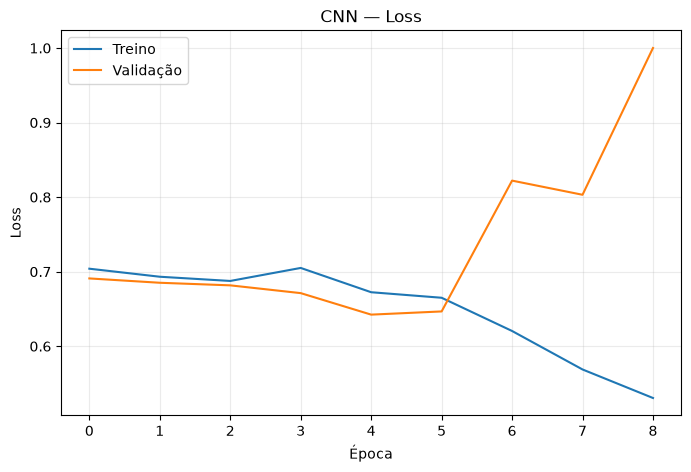

In [25]:
def plotar_historico_cnn(
    history
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Treino"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validação"
    )

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("CNN — Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Treino"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validação"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("CNN — Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


plotar_historico_cnn(
    history_cnn
)

# 25. Funções de avaliação da CNN

In [26]:
def obter_predicoes(
    modelo,
    dataset
):
    y_true = []
    y_prob = []

    inicio = time.perf_counter()

    for imagens, labels in dataset:
        probs = modelo.predict(
            imagens,
            verbose=0
        ).ravel()

        y_prob.extend(probs)

        y_true.extend(
            labels
            .numpy()
            .astype(int)
            .ravel()
        )

    tempo = (
        time.perf_counter()
        - inicio
    )

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    return (
        y_true,
        y_pred,
        y_prob,
        tempo
    )


def avaliar_cnn(
    modelo,
    dataset
):
    (
        y_true,
        y_pred,
        y_prob,
        tempo
    ) = obter_predicoes(
        modelo,
        dataset
    )

    metricas = {
        "modelo": "CNN do zero",
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "tempo_inferencia_s": tempo
    }

    display(
        pd.Series(metricas)
    )

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=
                CLASSIFICATION_NAMES,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=
            CLASSIFICATION_NAMES
    ).plot()

    plt.title(
        "CNN do zero"
    )

    plt.show()

    return (
        metricas,
        y_true,
        y_pred,
        y_prob
    )

# 26. Avaliação da CNN

modelo                CNN do zero
accuracy                    0.625
precision                0.666667
recall                        0.5
f1                       0.571429
tempo_inferencia_s       0.236836
dtype: object

              precision    recall  f1-score   support

      caneca       0.60      0.75      0.67         4
     garrafa       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



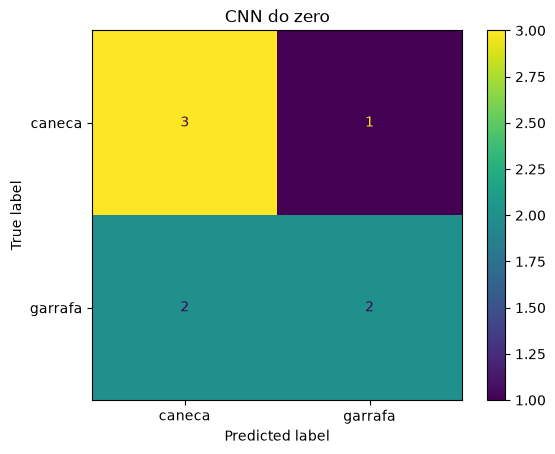

In [27]:
(
    metricas_cnn,
    y_true_cnn,
    y_pred_cnn,
    y_prob_cnn
) = avaliar_cnn(
    cnn_model,
    test_ds
)

# 27. Mostrar as imagens classificadas pela CNN

Além da matriz de confusão, esta etapa mostra cada imagem de teste com:

- classe real;
- classe prevista;
- probabilidade da classe `1`.

Isso ajuda a explicar os erros do modelo no relatório ou vídeo.

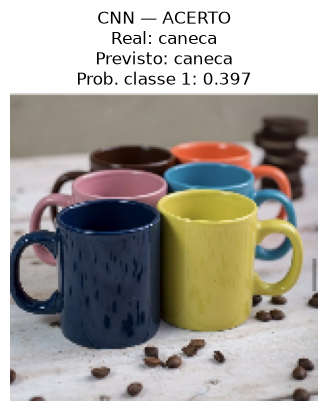

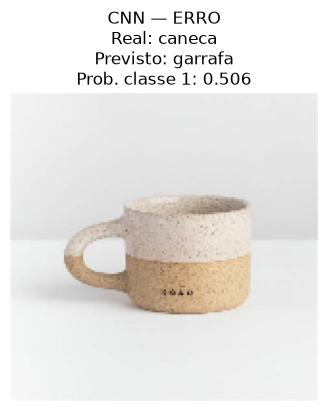

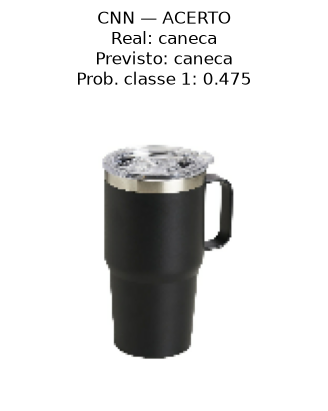

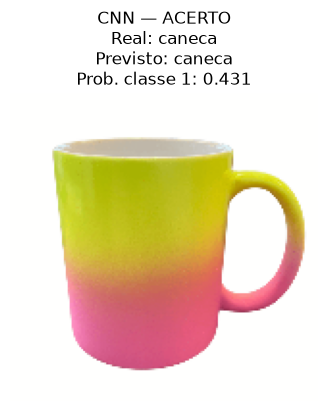

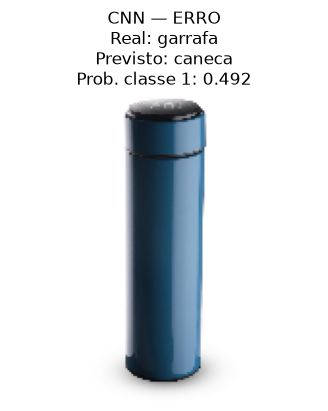

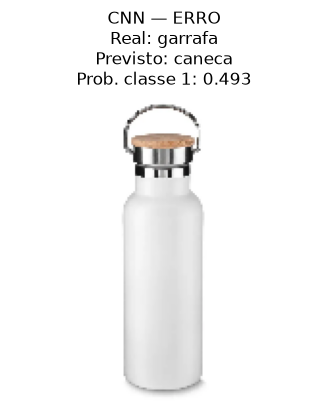

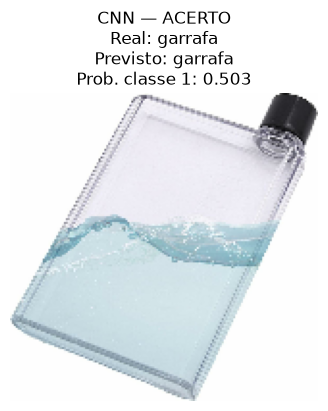

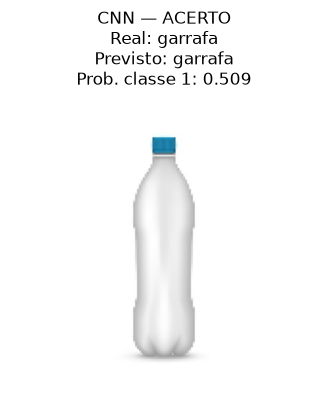

In [28]:
def mostrar_previsoes_cnn(
    modelo,
    dataset,
    max_imagens=8
):
    mostradas = 0

    for imagens, labels in dataset:
        probs = modelo.predict(
            imagens,
            verbose=0
        ).ravel()

        preds = (
            probs >= 0.5
        ).astype(int)

        for i in range(len(imagens)):
            real = int(
                labels[i]
                .numpy()
                .ravel()[0]
            )

            previsto = int(
                preds[i]
            )

            prob = float(
                probs[i]
            )

            plt.figure(
                figsize=(4, 4)
            )

            plt.imshow(
                imagens[i]
                .numpy()
                .astype("uint8")
            )

            status = (
                "ACERTO"
                if real == previsto
                else "ERRO"
            )

            plt.title(
                f"CNN — {status}\n"
                f"Real: "
                f"{CLASSIFICATION_NAMES[real]}\n"
                f"Previsto: "
                f"{CLASSIFICATION_NAMES[previsto]}\n"
                f"Prob. classe 1: "
                f"{prob:.3f}"
            )

            plt.axis("off")
            plt.show()

            mostradas += 1

            if mostradas >= max_imagens:
                return


mostrar_previsoes_cnn(
    cnn_model,
    test_ds,
    max_imagens=8
)

# 28. Comparação crítica — o que observar

## YOLO customizada 30 × 60 épocas

Compare:

- Precision;
- Recall;
- mAP@0.5;
- mAP@0.5:0.95;
- tempo de treinamento.

Mais épocas não significam automaticamente melhor resultado.

## YOLO customizada × YOLO padrão

A YOLO padrão foi treinada em um dataset genérico.

A YOLO customizada foi ajustada especificamente para as classes do projeto.

Observe:

- se ambas reconhecem os objetos;
- se alguma confunde as classes;
- qualidade das bounding boxes;
- confiança;
- tempo.

## CNN

A CNN resolve um problema diferente da YOLO:

- YOLO: localiza + classifica objetos;
- CNN: classifica a imagem inteira.

Por isso, as métricas não devem ser interpretadas como se os dois modelos realizassem exatamente a mesma tarefa.

# 29. Resumo numérico

In [29]:
resumo = pd.DataFrame([
    {
        "etapa": "YOLO 30 épocas",
        "melhor_mAP": score_30,
        "tempo_treino_s":
            TEMPO_TREINO_30
    },
    {
        "etapa": "YOLO 60 épocas",
        "melhor_mAP": score_60,
        "tempo_treino_s":
            TEMPO_TREINO_60
    },
    {
        "etapa": "CNN do zero",
        "accuracy":
            metricas_cnn["accuracy"],
        "precision":
            metricas_cnn["precision"],
        "recall":
            metricas_cnn["recall"],
        "f1":
            metricas_cnn["f1"],
        "tempo_treino_s":
            TEMPO_CNN
    }
])

display(resumo)

,etapa,melhor_mAP,tempo_treino_s,accuracy,precision,recall,f1
0,YOLO 30 épocas,0.24349,110.437590,NaN,NaN,NaN,NaN
1,YOLO 60 épocas,0.59187,204.206205,NaN,NaN,NaN,NaN
2,CNN do zero,NaN,6.906715,0.625,0.666667,0.5,0.571429


# 30. Conclusão — resultados obtidos

## YOLO 30 × 60 épocas

- **Melhor mAP@0.5:0.95 de 30 épocas:** 0.24349
- **Melhor mAP@0.5:0.95 de 60 épocas:** 0.59187
- **Tempo de treinamento de 30 épocas:** 110.44 segundos
- **Tempo de treinamento de 60 épocas:** 204.21 segundos
- **Experimento escolhido:** `fase6_60_final`

Houve evidência clara de ganho ao aumentar o treinamento de 30 para 60 épocas.

No conjunto de teste, o modelo de 30 épocas apresentou:

- Precision: 0.416
- Recall: 0.250
- mAP@0.5: 0.334
- mAP@0.5:0.95: 0.151

Já o modelo de 60 épocas apresentou:

- Precision: 0.562
- Recall: 0.625
- mAP@0.5: 0.585
- mAP@0.5:0.95: 0.395

Portanto, o modelo de 60 épocas apresentou melhor capacidade de detecção e localização dos objetos no conjunto de teste. Apesar de ter levado aproximadamente o dobro do tempo de treinamento, o ganho nas métricas foi significativo.

Os gráficos também mostram que o modelo de 60 épocas continuou evoluindo após a época 30. A Precision, o Recall e principalmente o mAP continuaram aumentando, enquanto o modelo de 30 épocas ainda apresentava bastante instabilidade.

---

## YOLO customizada

A YOLO customizada apresentou resultados melhores após o treinamento de 60 épocas.

### Garrafas

O modelo conseguiu detectar corretamente as quatro imagens de garrafas apresentadas no teste visual.

Foram observadas detecções como:

- `garrafa1.jpg`: garrafa, confiança aproximada de 0.61;
- `garrafa2.jpg`: garrafa, confiança aproximada de 0.45;
- `garrafa3.jpg`: garrafa, confiança aproximada de 0.64;
- `garrafa4.jpg`: garrafa, confiança aproximada de 0.27.

Isso mostra que o modelo aprendeu a classe `garrafa`, inclusive em objetos com formatos, cores e materiais diferentes.

A confiança de `garrafa4.jpg`, entretanto, foi baixa, indicando que o modelo ainda possui incerteza em algumas imagens.

### Canecas

O desempenho com as canecas foi mais irregular.

- `caneca2.jpg` teve as duas canecas identificadas;
- `caneca4.jpg` foi detectada corretamente;
- `caneca1.jpg` teve a caneca detectada, mas também ocorreu uma segunda detecção incorreta sobre uma região da mesa;
- `caneca3.jpg` não foi detectada com o threshold utilizado.

Portanto, a classe `caneca` ainda apresentou mais dificuldade do que a classe `garrafa`.

### Bounding boxes

De maneira geral, as bounding boxes ficaram adequadas nas detecções corretas e envolveram corretamente os objetos.

Entretanto, foram encontrados alguns problemas visuais:

- detecção duplicada em `caneca1.jpg`;
- uma bounding box falsa envolvendo parte da mesa em `caneca1.jpg`;
- ausência de detecção em `caneca3.jpg`;
- algumas detecções com confiança relativamente baixa.

Esses erros são compatíveis com o tamanho reduzido do dataset e com a variedade visual das imagens.

---

## YOLO padrão

A YOLO padrão pré-treinada apresentou bom desempenho em algumas imagens, principalmente nas canecas.

Ela reconheceu:

- `caneca1.jpg` como `cup`, com alta confiança;
- as duas canecas de `caneca2.jpg`;
- `caneca3.jpg` como `cup`;
- `caneca4.jpg` como `cup`;
- `garrafa1.jpg` como `bottle`;
- `garrafa4.jpg` como `bottle`.

Entretanto, também ocorreram erros.

Em `caneca1.jpg`, além da caneca, o modelo identificou a mesa como `dining table`, gerando uma detecção adicional que não fazia parte das classes de interesse do projeto.

Em `garrafa2.jpg`, nenhuma detecção foi realizada.

Em `garrafa3.jpg`, o objeto foi identificado como `vase` em vez de `bottle`.

Isso mostra uma diferença importante entre a YOLO padrão e a YOLO customizada.

A YOLO padrão possui conhecimento sobre muitas classes do dataset COCO e, por isso, pode reconhecer objetos semelhantes com nomes diferentes. Já a YOLO customizada foi treinada especificamente para utilizar apenas:

- `garrafa`;
- `caneca`.

No caso de `garrafa3.jpg`, por exemplo, a YOLO padrão interpretou o formato como um vaso, enquanto a customizada reconheceu corretamente a classe definida no projeto como `garrafa`.

Assim, mesmo que a YOLO padrão apresente alta confiança em algumas imagens, a YOLO customizada ficou mais alinhada ao problema específico do projeto.

---

## CNN do zero

A CNN criada do zero apresentou os seguintes resultados no conjunto de teste:

- **Accuracy:** 0.625
- **Precision:** 0.6667
- **Recall:** 0.5000
- **F1-score:** 0.5714

Isso corresponde a 5 classificações corretas em um conjunto com 8 imagens.

A matriz de confusão mostrou:

### Canecas

Das 4 imagens de canecas:

- 3 foram classificadas corretamente como caneca;
- 1 foi classificada incorretamente como garrafa.

### Garrafas

Das 4 imagens de garrafas:

- 2 foram classificadas corretamente como garrafa;
- 2 foram classificadas incorretamente como caneca.

Portanto, a CNN teve maior dificuldade em reconhecer garrafas.

### Overfitting

Também existem sinais de overfitting.

Nas últimas épocas:

- a accuracy de treinamento continuou aumentando, chegando a aproximadamente 0.72;
- a loss de treinamento continuou diminuindo;
- a accuracy de validação permaneceu em aproximadamente 0.625 e depois caiu para 0.50;
- a loss de validação aumentou fortemente, chegando aproximadamente a 1.0.

Isso indica que, após algumas épocas, o modelo começou a se ajustar excessivamente às imagens de treinamento, sem melhorar sua capacidade de generalização.

O comportamento começa a ficar mais evidente aproximadamente após a época 5 ou 6.

O EarlyStopping foi importante nesse caso, pois interrompeu o treinamento antes das 20 épocas máximas.

### Imagens classificadas incorretamente

Entre os exemplos apresentados, ocorreram erros em:

- uma imagem de caneca, classificada como garrafa, com probabilidade muito próxima do limite de decisão;
- duas imagens de garrafa, classificadas como caneca.

As probabilidades ficaram muito próximas de `0.5`, como aproximadamente:

- 0.506;
- 0.492;
- 0.493.

Isso mostra que o modelo estava bastante indeciso nessas imagens.

Uma possível causa é o pequeno número de imagens disponíveis para treinamento, além da grande variedade de formatos existentes entre garrafas e canecas.

---

## Análise crítica

YOLO e CNN não devem ser comparadas como se resolvessem exatamente o mesmo problema.

A YOLO realiza duas tarefas simultaneamente:

1. localiza o objeto dentro da imagem por meio de uma bounding box;
2. classifica o objeto encontrado.

Já a CNN utilizada neste projeto realiza apenas classificação.

Ela recebe a imagem inteira e informa se considera a imagem pertencente à classe `caneca` ou `garrafa`.

Por isso, métricas como mAP são adequadas para a YOLO, enquanto Accuracy, Precision, Recall e F1-score são utilizadas na CNN.

### Comparação geral

A YOLO customizada com 60 épocas apresentou uma evolução significativa em relação ao treinamento de 30 épocas.

Ela também demonstrou vantagem sobre a YOLO padrão em alguns casos por estar adaptada especificamente às classes utilizadas no projeto.

A YOLO padrão possui um conhecimento visual mais amplo e apresentou alta confiança em diversas canecas, porém também identificou objetos usando classes que não pertencem ao projeto, como `vase` e `dining table`.

A CNN do zero apresentou desempenho razoável, com Accuracy de 62.5%, mas demonstrou sinais de overfitting e dificuldade principalmente na diferenciação de algumas garrafas.

### Limitações

Os resultados devem ser interpretados considerando algumas limitações importantes:

- o dataset possui apenas 80 imagens;
- são apenas 64 imagens de treinamento;
- o conjunto de validação possui somente 8 imagens;
- o conjunto de teste possui somente 8 imagens;
- pequenas variações de apenas uma imagem alteram bastante as métricas;
- o treinamento foi realizado somente em CPU;
- foi necessário utilizar uma versão mais leve da YOLO e resolução de 320 pixels;
- a qualidade das bounding boxes utilizadas como labels afeta diretamente o aprendizado da YOLO;
- existe grande variação visual entre os objetos de uma mesma classe;
- o dataset ainda poderia ser ampliado com mais ângulos, fundos, cores, materiais e formatos.

Apesar dessas limitações, os experimentos demonstraram que aumentar o treinamento da YOLO de 30 para 60 épocas trouxe uma melhoria significativa e que a customização do modelo permitiu adaptar suas classes ao problema específico de identificação de garrafas e canecas.

# 31. Checklist da entrega principal

## Entrega 1 — YOLO customizada

- [x] labels conferidos
- [x] bounding boxes revisadas
- [x] treino com 30 épocas
- [x] treino com 60 épocas
- [x] Precision comparada
- [x] Recall comparado
- [x] mAP comparado
- [x] teste dos dois modelos
- [x] melhor modelo selecionado
- [x] imagens de detecção mostradas

## Entrega 2

- [x] YOLO padrão executada
- [x] imagens da YOLO padrão mostradas
- [x] CNN do zero treinada
- [x] Accuracy
- [x] Precision
- [x] Recall
- [x] F1-score
- [x] matriz de confusão
- [x] imagens de teste com previsão
- [x] comparação crítica final